In [ ]:
# ============================================================
# CELL 1: IMPORT REQUIRED LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

pd.set_option("display.max_columns", None)

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
# ============================================================
# CELL 2: IDENTIFY PROJECT ROOT AND DATASET PATH
# ============================================================

CURRENT_DIR = Path.cwd()

print("Current Working Directory:")
print(CURRENT_DIR)

# Find project root dynamically
PROJECT_ROOT = CURRENT_DIR

while not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATASET_PATH = PROJECT_ROOT / "data" / "raw" / "cmapss"

print("\nProject Root:")
print(PROJECT_ROOT)

print("\nDataset Path:")
print(DATASET_PATH)

print("\nDataset folder exists:", DATASET_PATH.exists())

Current Working Directory:
c:\Users\ACIAGO\Desktop\Aerospace_Predictive_Maintenance_Analytics\notebooks\phase_01

Project Root:
c:\Users\ACIAGO\Desktop\Aerospace_Predictive_Maintenance_Analytics

Dataset Path:
c:\Users\ACIAGO\Desktop\Aerospace_Predictive_Maintenance_Analytics\data\raw\cmapss

Dataset folder exists: True


In [ ]:
# ============================================================
# CELL 3: DEFINE CMAPSS COLUMN NAMES
# ============================================================

COLUMN_NAMES = [
    "engine_id",
    "cycle",
    "operational_setting_1",
    "operational_setting_2",
    "operational_setting_3",
    
    "sensor_1",
    "sensor_2",
    "sensor_3",
    "sensor_4",
    "sensor_5",
    "sensor_6",
    "sensor_7",
    "sensor_8",
    "sensor_9",
    "sensor_10",
    "sensor_11",
    "sensor_12",
    "sensor_13",
    "sensor_14",
    "sensor_15",
    "sensor_16",
    "sensor_17",
    "sensor_18",
    "sensor_19",
    "sensor_20",
    "sensor_21"
]

print("Total columns:", len(COLUMN_NAMES))
print("\nColumn Names:")
print(COLUMN_NAMES)

Total columns: 26

Column Names:
['engine_id', 'cycle', 'operational_setting_1', 'operational_setting_2', 'operational_setting_3', 'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21']


In [9]:
# ============================================================
# CELL 4: DEFINE DATASET FILES
# ============================================================

DATASETS = ["FD001", "FD002", "FD003", "FD004"]

FILE_PATHS = {}

for dataset in DATASETS:
    
    FILE_PATHS[dataset] = {
        "train": DATASET_PATH / f"train_{dataset}.txt",
        "test": DATASET_PATH / f"test_{dataset}.txt",
        "rul": DATASET_PATH / f"RUL_{dataset}.txt"
    }

print("Dataset files configured successfully!\n")

for dataset, paths in FILE_PATHS.items():
    print(dataset)
    for file_type, path in paths.items():
        print(f"  {file_type}: {path.name}")

Dataset files configured successfully!

FD001
  train: train_FD001.txt
  test: test_FD001.txt
  rul: RUL_FD001.txt
FD002
  train: train_FD002.txt
  test: test_FD002.txt
  rul: RUL_FD002.txt
FD003
  train: train_FD003.txt
  test: test_FD003.txt
  rul: RUL_FD003.txt
FD004
  train: train_FD004.txt
  test: test_FD004.txt
  rul: RUL_FD004.txt


In [10]:
# ============================================================
# CELL 5: FUNCTION TO LOAD CMAPSS DATA
# ============================================================

def load_cmapss_data(file_path):
    
    df = pd.read_csv(
        file_path,
        sep=r"\s+",
        header=None,
        names=COLUMN_NAMES
    )
    
    return df


def load_rul_data(file_path):
    
    df = pd.read_csv(
        file_path,
        sep=r"\s+",
        header=None,
        names=["RUL"]
    )
    
    return df


print("Loading functions created successfully!")

Loading functions created successfully!


In [11]:
# ============================================================
# CELL 6: LOAD ALL TRAIN, TEST AND RUL DATASETS
# ============================================================

train_data = {}
test_data = {}
rul_data = {}

for dataset in DATASETS:
    
    train_data[dataset] = load_cmapss_data(
        FILE_PATHS[dataset]["train"]
    )
    
    test_data[dataset] = load_cmapss_data(
        FILE_PATHS[dataset]["test"]
    )
    
    rul_data[dataset] = load_rul_data(
        FILE_PATHS[dataset]["rul"]
    )


print("All datasets loaded successfully!")

All datasets loaded successfully!


In [12]:
# ============================================================
# CELL 7: BASIC DATASET OVERVIEW
# ============================================================

overview = []

for dataset in DATASETS:
    
    overview.append({
        "Dataset": dataset,
        "Train Rows": train_data[dataset].shape[0],
        "Train Columns": train_data[dataset].shape[1],
        "Train Engines": train_data[dataset]["engine_id"].nunique(),
        
        "Test Rows": test_data[dataset].shape[0],
        "Test Columns": test_data[dataset].shape[1],
        "Test Engines": test_data[dataset]["engine_id"].nunique(),
        
        "RUL Values": len(rul_data[dataset])
    })

overview_df = pd.DataFrame(overview)

overview_df

,Dataset,Train Rows,Train Columns,Train Engines,Test Rows,Test Columns,Test Engines,RUL Values
0,FD001,20631,26,100,13096,26,100,100
1,FD002,53759,26,260,33991,26,259,259
2,FD003,24720,26,100,16596,26,100,100
3,FD004,61249,26,249,41214,26,248,248


In [13]:
# ============================================================
# CELL 8: VIEW SAMPLE DATA
# ============================================================

print("FD001 TRAIN DATA:\n")

display(train_data["FD001"].head())

print("\nFD001 DATA TYPES:\n")

train_data["FD001"].info()

FD001 TRAIN DATA:



,engine_id,cycle,operational_setting_1,operational_setting_2,operational_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044



FD001 DATA TYPES:

<class 'pandas.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 26 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   engine_id              20631 non-null  int64  
 1   cycle                  20631 non-null  int64  
 2   operational_setting_1  20631 non-null  float64
 3   operational_setting_2  20631 non-null  float64
 4   operational_setting_3  20631 non-null  float64
 5   sensor_1               20631 non-null  float64
 6   sensor_2               20631 non-null  float64
 7   sensor_3               20631 non-null  float64
 8   sensor_4               20631 non-null  float64
 9   sensor_5               20631 non-null  float64
 10  sensor_6               20631 non-null  float64
 11  sensor_7               20631 non-null  float64
 12  sensor_8               20631 non-null  float64
 13  sensor_9               20631 non-null  float64
 14  sensor_10              20631 non-null  float6

In [14]:
# ============================================================
# CELL 9: DATA QUALITY CHECK
# ============================================================

quality_results = []

for dataset in DATASETS:
    
    df = train_data[dataset]
    
    missing_values = df.isnull().sum().sum()
    
    duplicate_rows = df.duplicated().sum()
    
    duplicate_engine_cycle = df.duplicated(
        subset=["engine_id", "cycle"]
    ).sum()
    
    quality_results.append({
        "Dataset": dataset,
        "Missing Values": missing_values,
        "Duplicate Rows": duplicate_rows,
        "Duplicate Engine-Cycle Records": duplicate_engine_cycle
    })


quality_df = pd.DataFrame(quality_results)

quality_df

,Dataset,Missing Values,Duplicate Rows,Duplicate Engine-Cycle Records
0,FD001,0,0,0
1,FD002,0,0,0
2,FD003,0,0,0
3,FD004,0,0,0


In [15]:
# ============================================================
# CELL 10: ANALYZE ENGINE TRAJECTORY LENGTHS
# ============================================================

trajectory_results = []

for dataset in DATASETS:
    
    df = train_data[dataset]
    
    trajectory_length = (
        df.groupby("engine_id")["cycle"]
        .max()
    )
    
    trajectory_results.append({
        "Dataset": dataset,
        "Engines": trajectory_length.count(),
        "Minimum Cycles": trajectory_length.min(),
        "Maximum Cycles": trajectory_length.max(),
        "Average Cycles": round(trajectory_length.mean(), 2),
        "Median Cycles": trajectory_length.median()
    })


trajectory_df = pd.DataFrame(trajectory_results)

trajectory_df

,Dataset,Engines,Minimum Cycles,Maximum Cycles,Average Cycles,Median Cycles
0,FD001,100,128,362,206.31,199.0
1,FD002,260,128,378,206.77,199.0
2,FD003,100,145,525,247.20,220.5
3,FD004,249,128,543,245.98,234.0


In [16]:
# ============================================================
# CELL 11: PROFILE OPERATIONAL SETTINGS
# ============================================================

operational_columns = [
    "operational_setting_1",
    "operational_setting_2",
    "operational_setting_3"
]

for dataset in DATASETS:
    
    print("=" * 70)
    print(f"{dataset} - OPERATIONAL SETTINGS")
    print("=" * 70)
    
    display(
        train_data[dataset][operational_columns]
        .describe()
    )

FD001 - OPERATIONAL SETTINGS


,operational_setting_1,operational_setting_2,operational_setting_3
count,20631.000000,20631.000000,20631.0
mean,-0.000009,0.000002,100.0
std,0.002187,0.000293,0.0
min,-0.008700,-0.000600,100.0
25%,-0.001500,-0.000200,100.0
50%,0.000000,0.000000,100.0
75%,0.001500,0.000300,100.0
max,0.008700,0.000600,100.0


FD002 - OPERATIONAL SETTINGS


,operational_setting_1,operational_setting_2,operational_setting_3
count,53759.000000,53759.000000,53759.000000
mean,23.998407,0.572056,94.046020
std,14.747376,0.310016,14.237735
min,0.000000,0.000000,60.000000
25%,10.004600,0.250700,100.000000
50%,25.001300,0.700000,100.000000
75%,41.998000,0.840000,100.000000
max,42.008000,0.842000,100.000000


FD003 - OPERATIONAL SETTINGS


,operational_setting_1,operational_setting_2,operational_setting_3
count,24720.000000,24720.000000,24720.0
mean,-0.000024,0.000005,100.0
std,0.002194,0.000294,0.0
min,-0.008600,-0.000600,100.0
25%,-0.001500,-0.000200,100.0
50%,-0.000000,-0.000000,100.0
75%,0.001500,0.000300,100.0
max,0.008600,0.000700,100.0


FD004 - OPERATIONAL SETTINGS


,operational_setting_1,operational_setting_2,operational_setting_3
count,61249.000000,61249.000000,61249.000000
mean,23.999823,0.571347,94.031576
std,14.780722,0.310703,14.251954
min,0.000000,0.000000,60.000000
25%,10.004600,0.250700,100.000000
50%,25.001400,0.700000,100.000000
75%,41.998100,0.840000,100.000000
max,42.008000,0.842000,100.000000


In [17]:
# ============================================================
# CELL 12: SENSOR STATISTICS AND CONSTANT FEATURE DETECTION
# ============================================================

sensor_columns = [
    col for col in COLUMN_NAMES
    if col.startswith("sensor_")
]

sensor_analysis = []

for dataset in DATASETS:
    
    df = train_data[dataset]
    
    for sensor in sensor_columns:
        
        sensor_analysis.append({
            "Dataset": dataset,
            "Sensor": sensor,
            "Min": df[sensor].min(),
            "Max": df[sensor].max(),
            "Mean": df[sensor].mean(),
            "Std Dev": df[sensor].std(),
            "Unique Values": df[sensor].nunique()
        })


sensor_stats_df = pd.DataFrame(sensor_analysis)

sensor_stats_df.head(10)

,Dataset,Sensor,Min,Max,Mean,Std Dev,Unique Values
0,FD001,sensor_1,518.67,518.67,518.670000,0.000000e+00,1
1,FD001,sensor_2,641.21,644.53,642.680934,5.000533e-01,310
2,FD001,sensor_3,1571.04,1616.91,1590.523119,6.131150e+00,3012
3,FD001,sensor_4,1382.25,1441.49,1408.933782,9.000605e+00,4051
4,FD001,sensor_5,14.62,14.62,14.620000,5.329200e-15,1
5,FD001,sensor_6,21.60,21.61,21.609803,1.388985e-03,2
6,FD001,sensor_7,549.85,556.06,553.367711,8.850923e-01,513
7,FD001,sensor_8,2387.90,2388.56,2388.096652,7.098548e-02,53
8,FD001,sensor_9,9021.73,9244.59,9065.242941,2.208288e+01,6403
9,FD001,sensor_10,1.30,1.30,1.300000,0.000000e+00,1


In [18]:
# ============================================================
# CELL 13: IDENTIFY CONSTANT AND LOW-VARIABILITY SENSORS
# ============================================================

feature_results = []

for dataset in DATASETS:
    
    df = train_data[dataset]
    
    for sensor in sensor_columns:
        
        std_value = df[sensor].std()
        
        if df[sensor].nunique() <= 1:
            feature_type = "Constant"
        
        elif std_value < 0.01:
            feature_type = "Low Variability"
        
        else:
            feature_type = "Variable"
        
        feature_results.append({
            "Dataset": dataset,
            "Sensor": sensor,
            "Standard Deviation": std_value,
            "Feature Type": feature_type
        })


feature_analysis_df = pd.DataFrame(feature_results)

feature_analysis_df

,Dataset,Sensor,Standard Deviation,Feature Type
0,FD001,sensor_1,0.000000e+00,Constant
1,FD001,sensor_2,5.000533e-01,Variable
2,FD001,sensor_3,6.131150e+00,Variable
3,FD001,sensor_4,9.000605e+00,Variable
4,FD001,sensor_5,5.329200e-15,Constant
...,...,...,...,...
79,FD004,sensor_17,2.780828e+01,Variable
80,FD004,sensor_18,1.454725e+02,Variable
81,FD004,sensor_19,5.369424e+00,Variable
82,FD004,sensor_20,9.936396e+00,Variable


In [19]:
# ============================================================
# CELL 14: TRAIN AND TEST STRUCTURE VALIDATION
# ============================================================

comparison_results = []

for dataset in DATASETS:
    
    train_df = train_data[dataset]
    test_df = test_data[dataset]
    
    same_columns = (
        list(train_df.columns) ==
        list(test_df.columns)
    )
    
    comparison_results.append({
        "Dataset": dataset,
        "Train Columns": train_df.shape[1],
        "Test Columns": test_df.shape[1],
        "Same Column Structure": same_columns,
        "Train Engines": train_df["engine_id"].nunique(),
        "Test Engines": test_df["engine_id"].nunique()
    })


comparison_df = pd.DataFrame(comparison_results)

comparison_df

,Dataset,Train Columns,Test Columns,Same Column Structure,Train Engines,Test Engines
0,FD001,26,26,True,100,100
1,FD002,26,26,True,260,259
2,FD003,26,26,True,100,100
3,FD004,26,26,True,249,248


In [20]:
# ============================================================
# CELL 15: ANALYZE RUL VALUES
# ============================================================

rul_summary = []

for dataset in DATASETS:
    
    rul_df = rul_data[dataset]
    
    rul_summary.append({
        "Dataset": dataset,
        "Total Engines": len(rul_df),
        "Minimum RUL": rul_df["RUL"].min(),
        "Maximum RUL": rul_df["RUL"].max(),
        "Average RUL": round(rul_df["RUL"].mean(), 2),
        "Median RUL": rul_df["RUL"].median()
    })


rul_summary_df = pd.DataFrame(rul_summary)

rul_summary_df

,Dataset,Total Engines,Minimum RUL,Maximum RUL,Average RUL,Median RUL
0,FD001,100,7,145,75.52,86.0
1,FD002,259,6,194,81.19,80.0
2,FD003,100,6,145,75.32,77.5
3,FD004,248,6,195,86.55,88.0


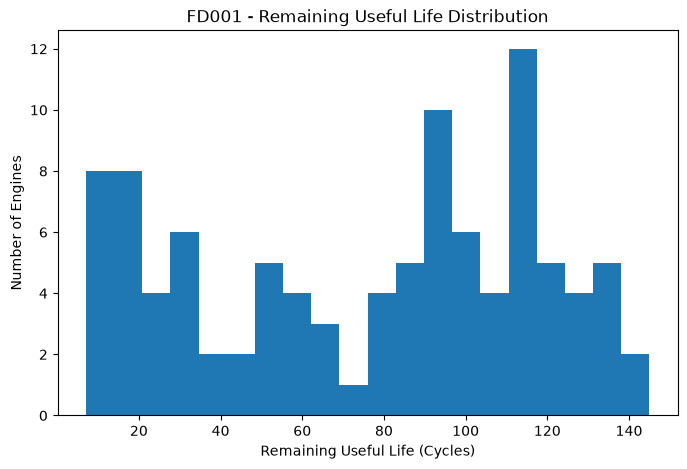

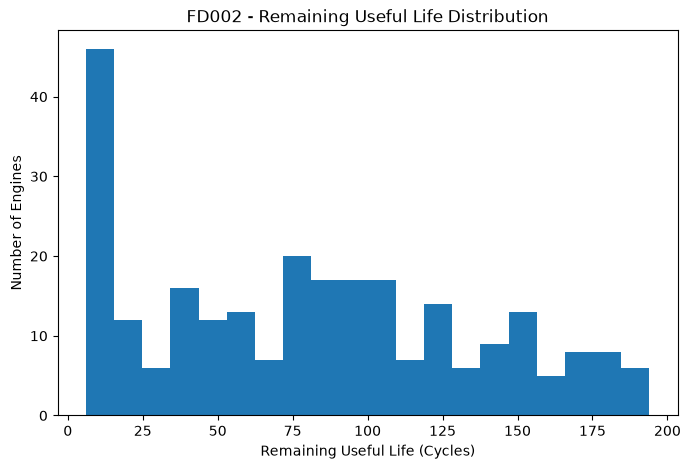

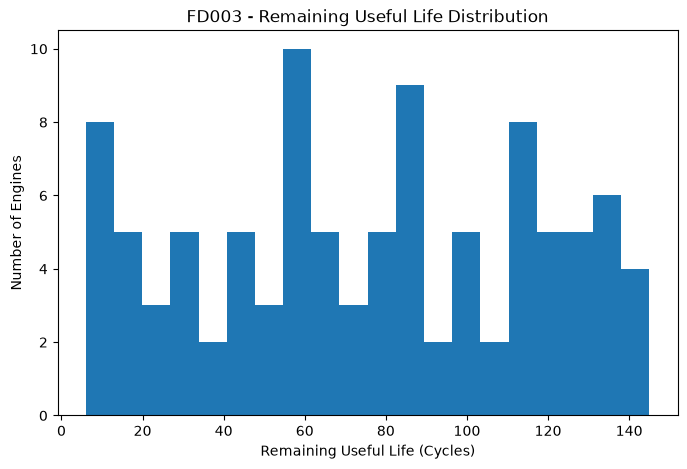

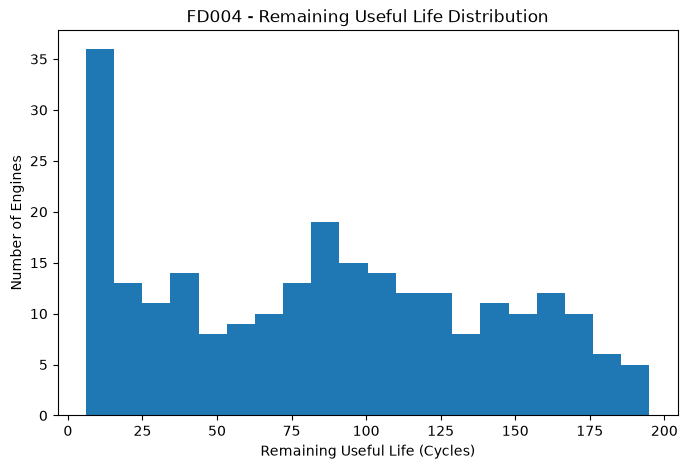

In [21]:
# ============================================================
# CELL 16: VISUALIZE RUL DISTRIBUTION
# ============================================================

for dataset in DATASETS:
    
    plt.figure(figsize=(8, 5))
    
    plt.hist(
        rul_data[dataset]["RUL"],
        bins=20
    )
    
    plt.title(f"{dataset} - Remaining Useful Life Distribution")
    
    plt.xlabel("Remaining Useful Life (Cycles)")
    
    plt.ylabel("Number of Engines")
    
    plt.show()

Selected sensors for initial trend visualization:
['sensor_9', 'sensor_14', 'sensor_4']


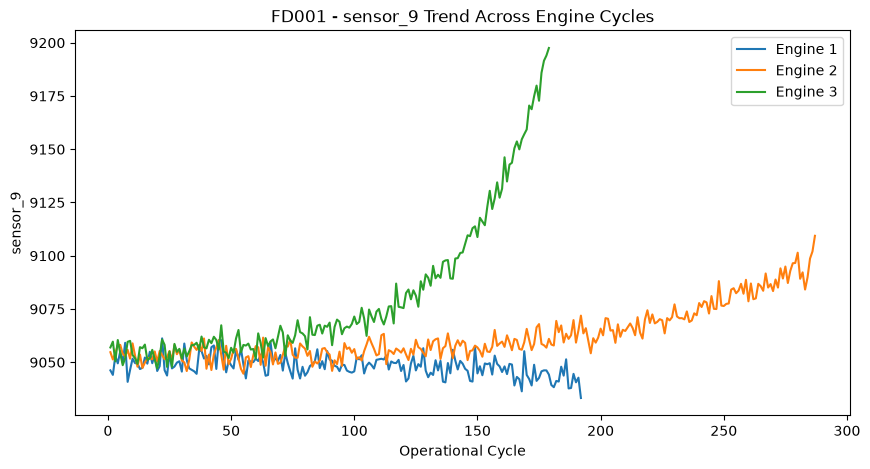

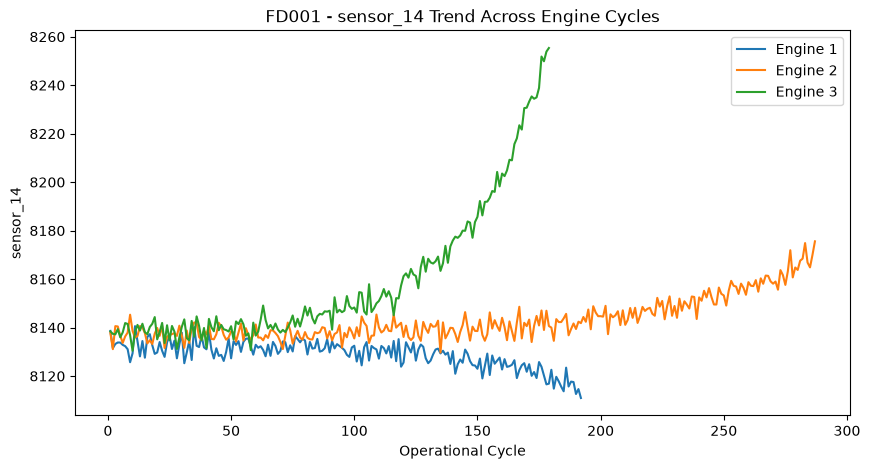

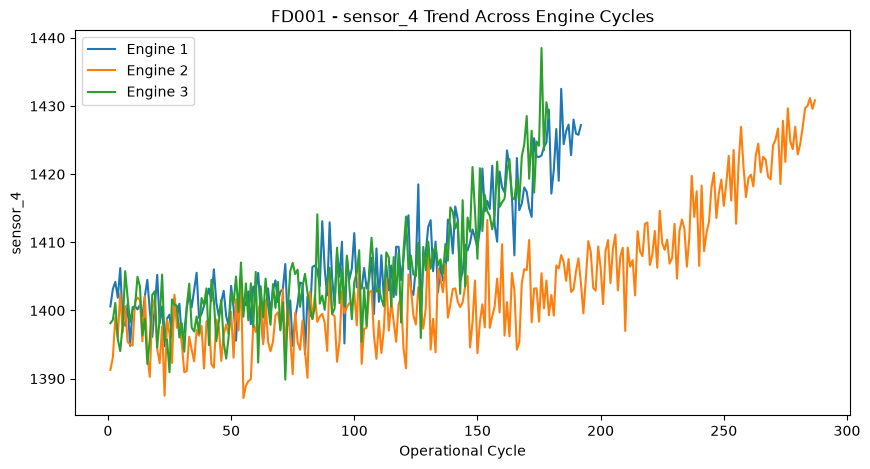

In [22]:
# ============================================================
# CELL 17: VISUALIZE ENGINE DEGRADATION / SENSOR TREND
# ============================================================

# Use FD001 because it is the simplest dataset:
# One operating condition
# One fault mode

df = train_data["FD001"]

# Find sensors with meaningful variation
sensor_variance = (
    df[sensor_columns]
    .std()
    .sort_values(ascending=False)
)

top_sensors = sensor_variance.head(3).index.tolist()

print("Selected sensors for initial trend visualization:")
print(top_sensors)

# Select a few example engines
sample_engines = [1, 2, 3]

for sensor in top_sensors:
    
    plt.figure(figsize=(10, 5))
    
    for engine_id in sample_engines:
        
        engine_data = df[
            df["engine_id"] == engine_id
        ]
        
        plt.plot(
            engine_data["cycle"],
            engine_data[sensor],
            label=f"Engine {engine_id}"
        )
    
    plt.title(f"FD001 - {sensor} Trend Across Engine Cycles")
    
    plt.xlabel("Operational Cycle")
    
    plt.ylabel(sensor)
    
    plt.legend()
    
    plt.show()

In [23]:
# ============================================================
# CELL 18: CREATE FINAL DATA QUALITY SUMMARY
# ============================================================

final_quality_summary = []

for dataset in DATASETS:
    
    df = train_data[dataset]
    
    constant_features = [
        sensor for sensor in sensor_columns
        if df[sensor].nunique() <= 1
    ]
    
    low_variability_features = [
        sensor for sensor in sensor_columns
        if df[sensor].std() < 0.01
        and df[sensor].nunique() > 1
    ]
    
    final_quality_summary.append({
        "Dataset": dataset,
        "Rows": df.shape[0],
        "Columns": df.shape[1],
        "Engines": df["engine_id"].nunique(),
        "Missing Values": df.isnull().sum().sum(),
        "Duplicate Rows": df.duplicated().sum(),
        "Duplicate Engine-Cycle": df.duplicated(
            subset=["engine_id", "cycle"]
        ).sum(),
        "Constant Sensors": len(constant_features),
        "Low Variability Sensors": len(low_variability_features)
    })


final_quality_df = pd.DataFrame(final_quality_summary)

final_quality_df

,Dataset,Rows,Columns,Engines,Missing Values,Duplicate Rows,Duplicate Engine-Cycle,Constant Sensors,Low Variability Sensors
0,FD001,20631,26,100,0,0,0,6,1
1,FD002,53759,26,260,0,0,0,0,1
2,FD003,24720,26,100,0,0,0,5,1
3,FD004,61249,26,249,0,0,0,0,1


In [24]:
# ============================================================
# CELL 19: FINAL PHASE 1 VALIDATION
# ============================================================

print("=" * 80)
print("PHASE 1 - DATASET UNDERSTANDING SUMMARY")
print("=" * 80)

for dataset in DATASETS:
    
    train_df = train_data[dataset]
    test_df = test_data[dataset]
    rul_df = rul_data[dataset]
    
    print(f"\nDATASET: {dataset}")
    print("-" * 50)
    
    print(f"Train Engines: {train_df['engine_id'].nunique()}")
    print(f"Test Engines: {test_df['engine_id'].nunique()}")
    
    print(f"Train Records: {len(train_df)}")
    print(f"Test Records: {len(test_df)}")
    
    print(f"Columns: {train_df.shape[1]}")
    
    print(f"Missing Values: {train_df.isnull().sum().sum()}")
    
    print(
        "Duplicate Engine-Cycle Records:",
        train_df.duplicated(
            subset=['engine_id', 'cycle']
        ).sum()
    )
    
    print(f"RUL Records: {len(rul_df)}")
    
    print(
        "Train/Test Structure Match:",
        list(train_df.columns) == list(test_df.columns)
    )


print("\n" + "=" * 80)
print("PHASE 1 DATASET PROFILING COMPLETED SUCCESSFULLY!")
print("=" * 80)

PHASE 1 - DATASET UNDERSTANDING SUMMARY

DATASET: FD001
--------------------------------------------------
Train Engines: 100
Test Engines: 100
Train Records: 20631
Test Records: 13096
Columns: 26
Missing Values: 0
Duplicate Engine-Cycle Records: 0
RUL Records: 100
Train/Test Structure Match: True

DATASET: FD002
--------------------------------------------------
Train Engines: 260
Test Engines: 259
Train Records: 53759
Test Records: 33991
Columns: 26
Missing Values: 0
Duplicate Engine-Cycle Records: 0
RUL Records: 259
Train/Test Structure Match: True

DATASET: FD003
--------------------------------------------------
Train Engines: 100
Test Engines: 100
Train Records: 24720
Test Records: 16596
Columns: 26
Missing Values: 0
Duplicate Engine-Cycle Records: 0
RUL Records: 100
Train/Test Structure Match: True

DATASET: FD004
--------------------------------------------------
Train Engines: 249
Test Engines: 248
Train Records: 61249
Test Records: 41214
Columns: 26
Missing Values: 0
Duplicat